In [1]:
# 1. Setup & Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline
plt.rcParams['figure.figsize'] = (8,5)
sns.set(style="whitegrid")

In [2]:
# 2. Load dataset

path = "student-mat.csv"

# defensive loading (try a couple of separators common to this dataset)
for sep in [',', ';', '\t']:
    try:
        df = pd.read_csv(path, sep=sep)
        # small sanity check: dataset should have 'G3' column (final grade)
        if 'G3' in df.columns:
            print(f"Loaded with sep='{sep}' — shape: {df.shape}")
            break
    except Exception as e:
        last_exc = e
else:
    raise FileNotFoundError(f"Could not load '{path}'. Ensure the file is uploaded. Last error: {last_exc}")

# show top rows
df.head()

Loaded with sep=';' — shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# check for missing values
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Series([], dtype: int64)

In [4]:
# remove duplicates (if any)
initial_rows = df.shape[0]
df = df.drop_duplicates()
removed = initial_rows - df.shape[0]
print(f"Removed {removed} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (395, 33)


In [5]:
# shape and dtypes
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

Shape: (395, 33)

Column dtypes:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [6]:
# Quick conversions if needed: convert numeric-like columns, e.g., G1,G2,G3 are numeric
for col in ['G1','G2','G3']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
# confirm
df[['G1','G2','G3']].describe()

,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


In [7]:
# Average final grade (G3)
avg_g3 = df['G3'].mean()
avg_g3

np.float64(10.415189873417722)

In [8]:
# How many students scored above 15?
count_above_15 = (df['G3'] > 15).sum()
count_above_15, df.shape[0]

(np.int64(40), 395)

In [9]:
# Is study time correlated with performance?
# 'studytime' column in original dataset is ordinal: 1(<2h),2(2-5h),3(5-10h),4(>10h)
if 'studytime' in df.columns:
    # compute Pearson correlation between studytime and G3
    corr_study_g3 = df[['studytime','G3']].corr().loc['studytime','G3']
    corr_study_g3
else:
    corr_study_g3 = None
    print("Column 'studytime' not found.")
corr_study_g3

np.float64(0.09781968965319622)

In [10]:
# Which gender performs better on average?
if 'sex' in df.columns:
    avg_by_gender = df.groupby('sex')['G3'].mean().rename(index={'M':'Male','F':'Female'})
    avg_by_gender
else:
    avg_by_gender = None
    print("Column 'sex' not found.")

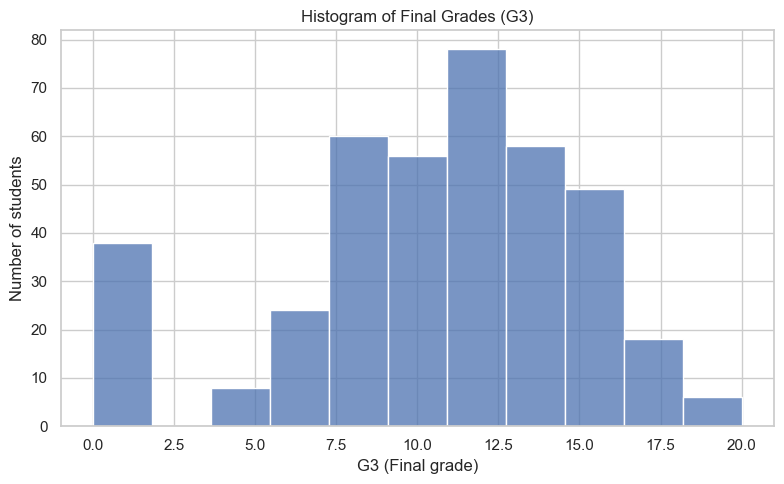

In [11]:
# Histogram of G3
plt.figure(figsize=(8,5))
sns.histplot(df['G3'].dropna(), bins=11, kde=False)
plt.title('Histogram of Final Grades (G3)')
plt.xlabel('G3 (Final grade)')
plt.ylabel('Number of students')
plt.tight_layout()
plt.show()

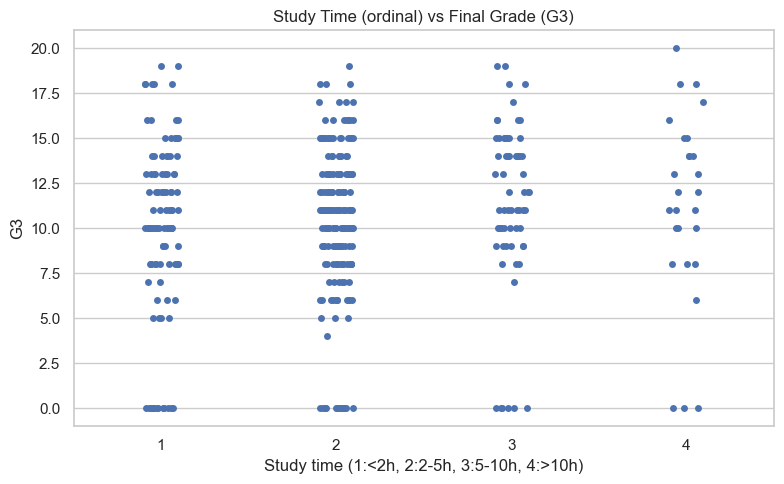

In [12]:
# Scatterplot: studytime vs G3 (jitter for readability)
if 'studytime' in df.columns:
    plt.figure(figsize=(8,5))
    sns.stripplot(x='studytime', y='G3', data=df, jitter=True)
    plt.title('Study Time (ordinal) vs Final Grade (G3)')
    plt.xlabel('Study time (1:<2h, 2:2-5h, 3:5-10h, 4:>10h)')
    plt.ylabel('G3')
    plt.tight_layout()
    plt.show()
else:
    print("No 'studytime' column for scatterplot.")

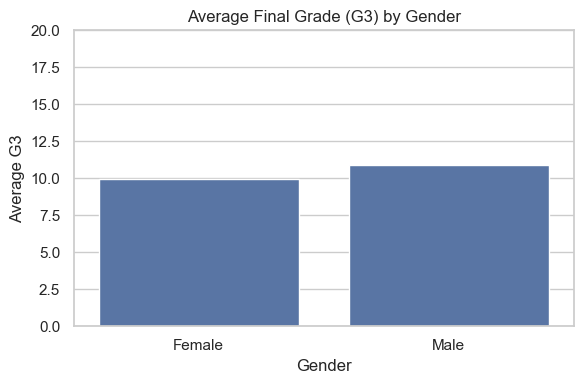

In [13]:
# Bar chart: average by gender
if avg_by_gender is not None:
    plt.figure(figsize=(6,4))
    sns.barplot(x=avg_by_gender.index, y=avg_by_gender.values)
    plt.title('Average Final Grade (G3) by Gender')
    plt.ylabel('Average G3')
    plt.xlabel('Gender')
    plt.ylim(0, 20)
    plt.tight_layout()
    plt.show()

In [14]:
print(f"Average final grade (G3): {avg_g3:.2f}")
print(f"Students scoring > 15: {count_above_15} / {df.shape[0]} ({count_above_15/df.shape[0]*100:.1f}%)")

if corr_study_g3 is not None:
    print(f"Correlation (studytime vs G3): {corr_study_g3:.3f} (Pearson)")

if avg_by_gender is not None:
    for sex, val in avg_by_gender.items():
        print(f"Average G3 — {sex}: {val:.2f}")

Average final grade (G3): 10.42
Students scoring > 15: 40 / 395 (10.1%)
Correlation (studytime vs G3): 0.098 (Pearson)
Average G3 — Female: 9.97
Average G3 — Male: 10.91
